## Alternate growing season visualisation

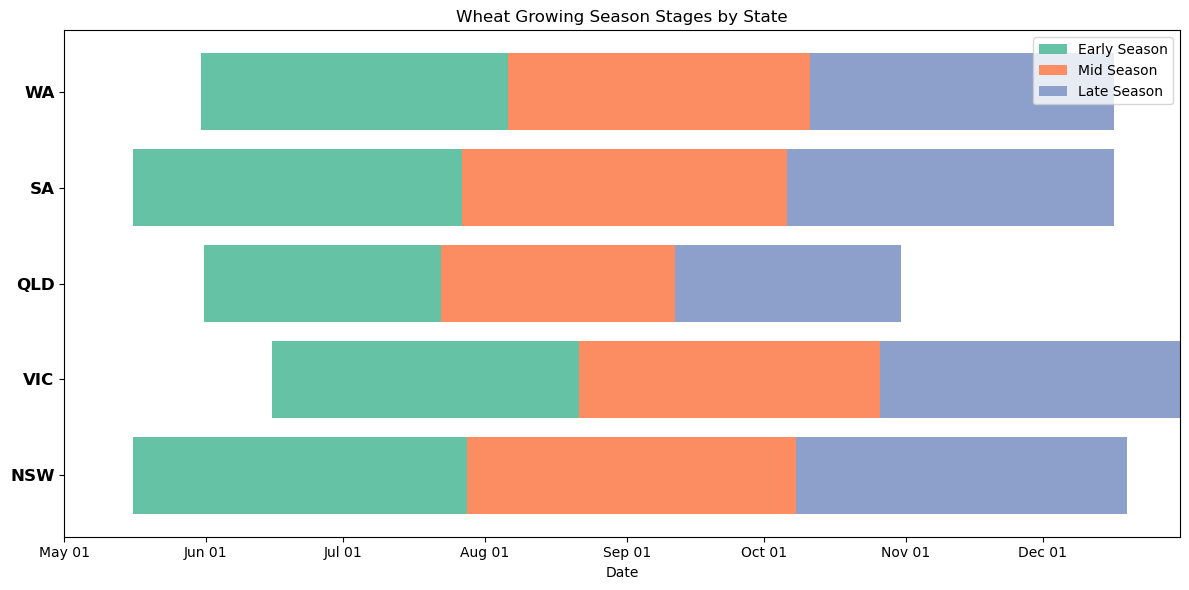

In [ ]:
state_points = {
    "NSW":  (-33.0, 147.0),
    "VIC":  (-36.5, 145.0),
    "QLD":  (-24.0, 148.0),
    "SA":   (-34.0, 138.0),
    "WA":   (-31.0, 118.0),
}

import datetime as dt

def doy_to_date(doy):
    return dt.datetime(2001, 1, 1) + pd.Timedelta(days=doy - 1)

def extract_value(da, lat, lon):
    return da.sel(lat=lat, lon=lon, method="nearest").item()

rows = []
start_season, start_mid, start_harv, end_season = season_dates
for state, (lat, lon) in state_points.items():
    rows.append({
        "state": state,
        "start_gs": extract_value(start_season, lat, lon),
        "start_mid": extract_value(start_mid, lat, lon),
        "start_harv": extract_value(start_harv, lat, lon),
        "end": extract_value(end_season, lat, lon),
    })

df = pd.DataFrame(rows)

import datetime as dt
import matplotlib.dates as mdates


def doy_to_date(doy):
    return dt.datetime(2001, 1, 1) + pd.Timedelta(days=doy - 1)


def plot_segment(ax, y, start_doy, end_doy, color, label=None):
    """Plot a horizontal bar segment, splitting if it crosses year-end."""
    start = doy_to_date(start_doy)
    end = doy_to_date(end_doy)

    year_end = dt.datetime(2001, 12, 31)
    year_start = dt.datetime(2001, 1, 1)

    if end_doy >= start_doy:
        # normal case
        ax.barh(y, end - start, left=start, color=color, label=label)
    else:
        # wrap-around case
        ax.barh(y, year_end - start, left=start, color=color, label=label)
        ax.barh(y, end - year_start, left=year_start, color=color)


fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "early":   "#66c2a5",
    "mid":     "#fc8d62",
    "harvest": "#8da0cb"
}

for i, row in df.iterrows():
    plot_segment(ax, i, row.start_gs, row.start_mid,
                 colors["early"], label="Early Season" if i == 0 else None)

    plot_segment(ax, i, row.start_mid, row.start_harv,
                 colors["mid"], label="Mid Season" if i == 0 else None)

    plot_segment(ax, i, row.start_harv, row.end,
                 colors["harvest"], label="Late Season" if i == 0 else None)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.state, fontweight="bold", fontsize=12)

# Format x-axis to show only month/day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlim(dt.datetime(2001,5,1), dt.datetime(2001,12,31))

ax.set_xlabel("Date")
ax.set_title("Wheat Growing Season Stages by State")

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()




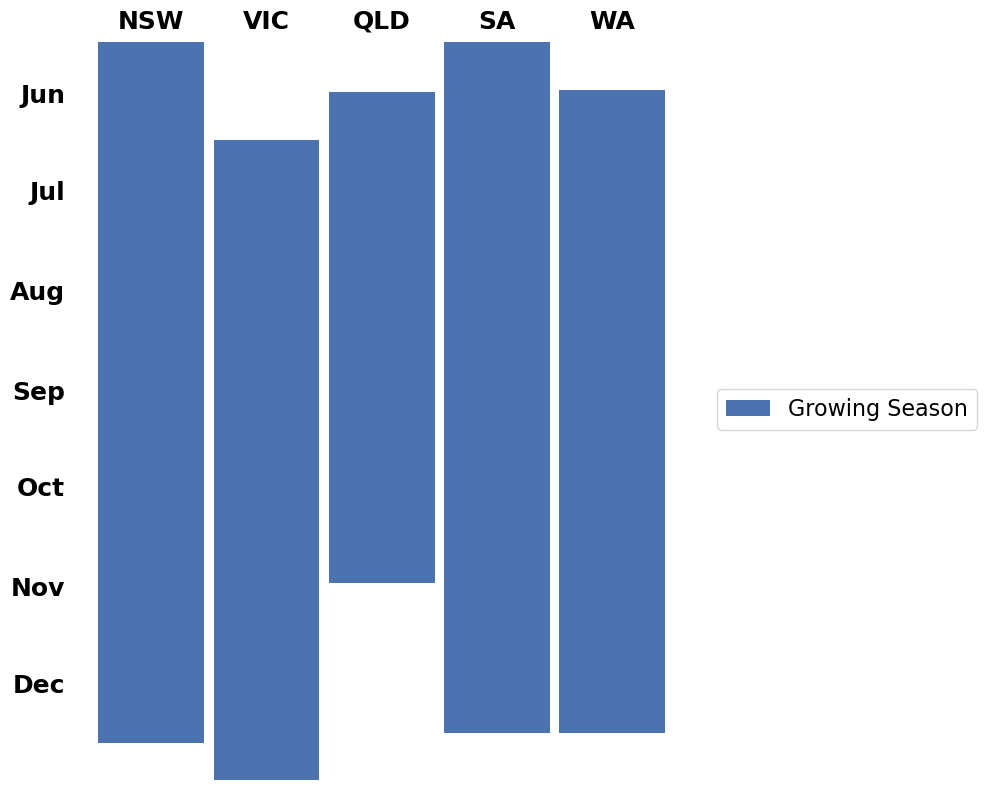

In [ ]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def doy_to_date(doy):
    return dt.datetime(2001, 1, 1) + pd.Timedelta(days=doy - 1)

def plot_full_season(ax, x, start_doy, end_doy, color, label=None):
    """Plot one full vertical bar for the entire growing season."""
    start = doy_to_date(start_doy)
    end = doy_to_date(end_doy)

    year_end = dt.datetime(2001, 12, 31)
    year_start = dt.datetime(2001, 1, 1)

    bar_width = 0.45  # keep your original width

    if end_doy >= start_doy:
        ax.bar(x, end - start, bottom=start, color=color,
               label=label, width=bar_width)
    else:
        # wrap-around case
        ax.bar(x, year_end - start, bottom=start, color=color,
               label=label, width=bar_width)
        ax.bar(x, end - year_start, bottom=year_start, color=color,
               width=bar_width)


fig, ax = plt.subplots(figsize=(10, 8))

# Single color for full season
season_color = "#4C72B0"

# Compressed x positions so states sit closer together
x_positions = np.linspace(0, len(df)-1, len(df)) * 0.49

# Plot one bar per state
for i, row in df.iterrows():
    x = x_positions[i]
    plot_full_season(ax, x, row.start_gs, row.end,
                     season_color, label="Growing Season" if i == 0 else None)

# X-axis: states (ticks at top)
ax.set_xticks(x_positions)
ax.set_xticklabels(df.state, fontweight="bold", fontsize=18)
ax.xaxis.tick_top()

# Y-axis: months only, bold, larger
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="y", labelsize=18)
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Date range (remove January)
ax.set_ylim(dt.datetime(2001,12,31), dt.datetime(2001,5,15))

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks but keep labels
ax.tick_params(axis="both", length=0)

# No title, no y-label
ax.set_ylabel("")
ax.set_title("")

# Legend outside plot
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=16)

plt.tight_layout()
plt.show()


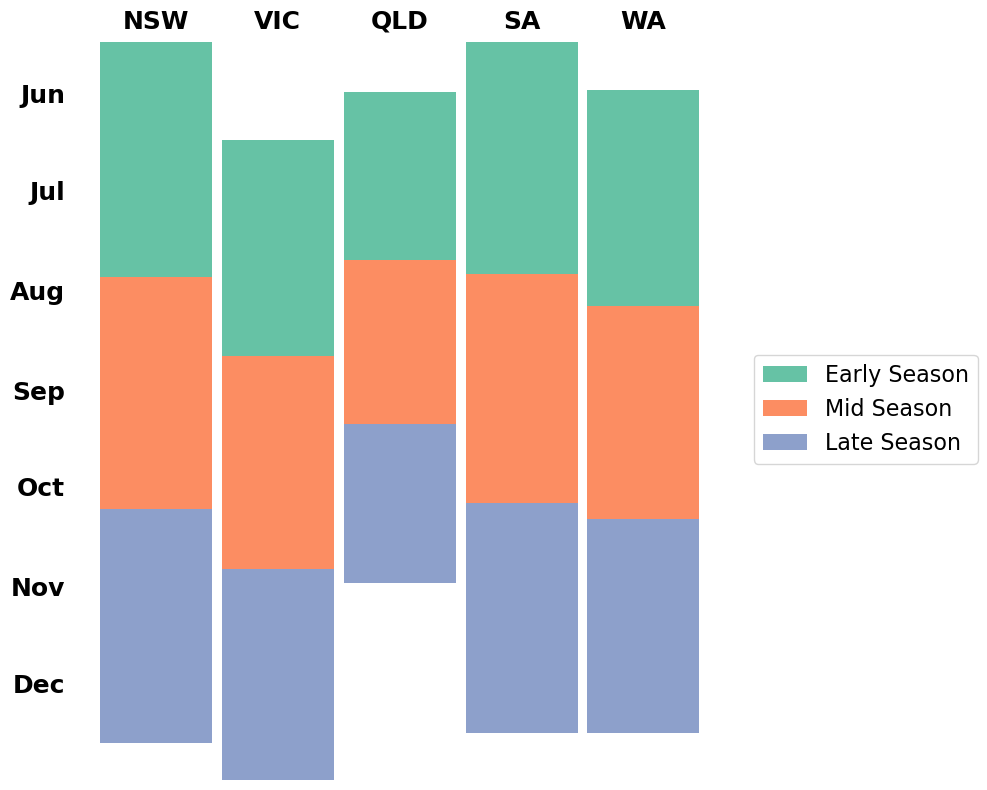

In [ ]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def doy_to_date(doy):
    return dt.datetime(2001, 1, 1) + pd.Timedelta(days=doy - 1)

def plot_segment_vertical(ax, x, start_doy, end_doy, color, label=None):
    """Plot a vertical bar segment, splitting if it crosses year-end."""
    start = doy_to_date(start_doy)
    end = doy_to_date(end_doy)

    year_end = dt.datetime(2001, 12, 31)
    year_start = dt.datetime(2001, 1, 1)

    bar_width = 0.45  # KEEP original width

    if end_doy >= start_doy:
        ax.bar(x, end - start, bottom=start, color=color,
               label=label, width=bar_width)
    else:
        ax.bar(x, year_end - start, bottom=start, color=color,
               label=label, width=bar_width)
        ax.bar(x, end - year_start, bottom=year_start, color=color,
               width=bar_width)


fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    "early":   "#66c2a5",
    "mid":     "#fc8d62",
    "harvest": "#8da0cb"
}

# Create compressed x positions for states
x_positions = np.linspace(0, len(df)-1, len(df)) * 0.49
for i, row in df.iterrows():
    x = x_positions[i]
    plot_segment_vertical(ax, x, row.start_gs, row.start_mid,
                          colors["early"], label="Early Season" if i == 0 else None)

    plot_segment_vertical(ax, x, row.start_mid, row.start_harv,
                          colors["mid"], label="Mid Season" if i == 0 else None)

    plot_segment_vertical(ax, x, row.start_harv, row.end,
                          colors["harvest"], label="Late Season" if i == 0 else None)

# # Plot each state as a vertical column
# for i, row in df.iterrows():
#     plot_segment_vertical(ax, i, row.start_gs, row.start_mid,
#                           colors["early"], label="Early Season" if i == 0 else None)

#     plot_segment_vertical(ax, i, row.start_mid, row.start_harv,
#                           colors["mid"], label="Mid Season" if i == 0 else None)

#     plot_segment_vertical(ax, i, row.start_harv, row.end,
#                           colors["harvest"], label="Late Season" if i == 0 else None)

# X-axis: states (ticks at top)
ax.set_xticks(x_positions)
ax.set_xticklabels(df.state, fontweight="bold", fontsize=18)
ax.xaxis.tick_top()



# Y-axis: months only, bold, larger
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="y", labelsize=18)
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Earliest date at top
ax.set_ylim(dt.datetime(2001,12,31), dt.datetime(2001,5,15))

# Remove all spines (no box)
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks but keep labels
ax.tick_params(axis="both", length=0)

# No title, no y-label
ax.set_ylabel("")
ax.set_title("")

# Legend outside plot (right side)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=16)

plt.tight_layout()
plt.show()


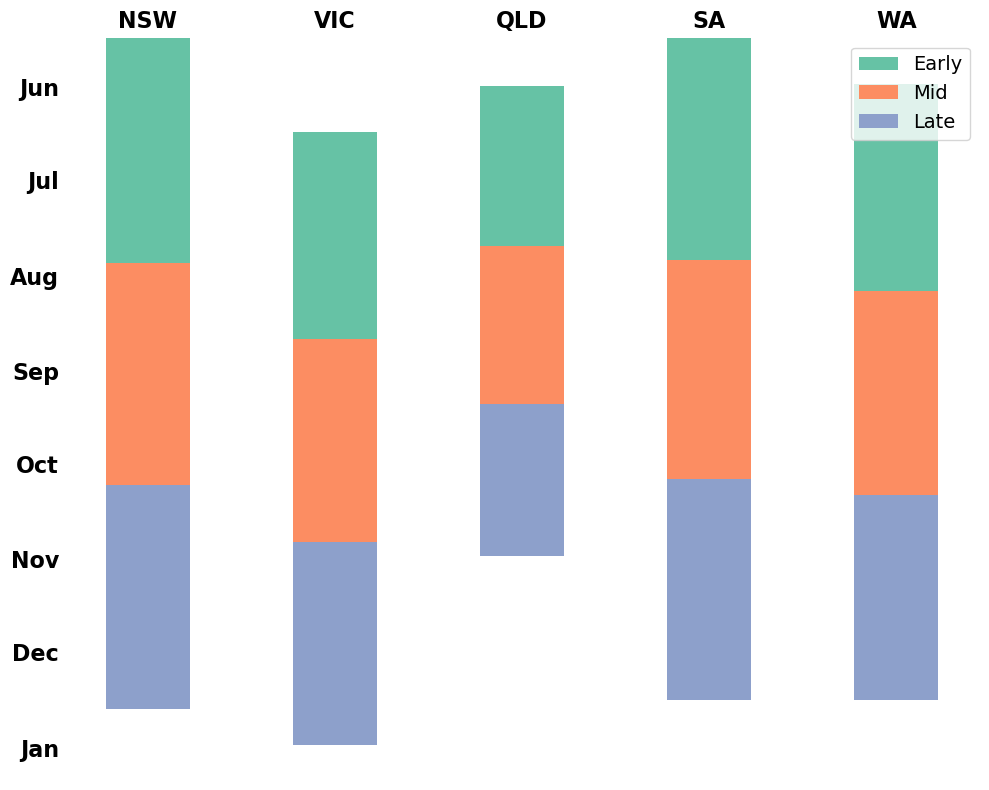

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt

def plot_segment_vertical(ax, x, start_doy, end_doy, color, label=None):
    """Plot a vertical bar segment, splitting if it crosses year-end."""
    start = doy_to_date(start_doy)
    end = doy_to_date(end_doy)

    year_end = dt.datetime(2001, 12, 31)
    year_start = dt.datetime(2001, 1, 1)

    bar_width = 0.45  # thinner bars

    if end_doy >= start_doy:
        ax.bar(x, end - start, bottom=start, color=color, label=label,
               width=bar_width)
    else:
        ax.bar(x, year_end - start, bottom=start, color=color,
               label=label, width=bar_width)
        ax.bar(x, end - year_start, bottom=year_start, color=color,
               width=bar_width)


fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    "early":   "#66c2a5",
    "mid":     "#fc8d62",
    "harvest": "#8da0cb"
}

for i, row in df.iterrows():
    plot_segment_vertical(ax, i, row.start_gs, row.start_mid,
                          colors["early"], label="Early" if i == 0 else None)

    plot_segment_vertical(ax, i, row.start_mid, row.start_harv,
                          colors["mid"], label="Mid" if i == 0 else None)

    plot_segment_vertical(ax, i, row.start_harv, row.end,
                          colors["harvest"], label="Late" if i == 0 else None)

# X-axis: states (ticks at top)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df.state, fontweight="bold", fontsize=16)
ax.xaxis.tick_top()

# Y-axis: months only, bold, larger
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="y", labelsize=16)
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Earliest date at top
ax.invert_yaxis()

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks but keep labels
ax.tick_params(axis="both", length=0)

# No title, no y-label
ax.set_ylabel("")
ax.set_title("")

# Larger legend
ax.legend(loc="upper right", fontsize=14)

plt.tight_layout()
plt.show()


## Yield Model Timeseries

In [ ]:
import pandas as pd

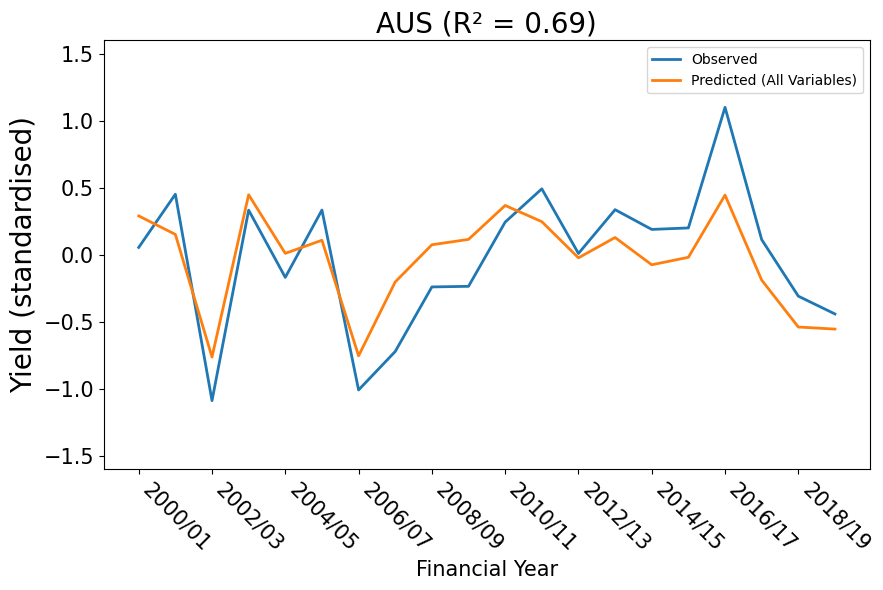

In [ ]:
perf_datadir = f'{datadir}/yield_model_analytics/performance_scores/'
aus_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/RandomForestRegressor_AUS_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
)
# ex_aus_yield = pd.read_csv(
#         f'{perf_datadir}/state_aggregated/extremes_only/full_season_only/single_drought_180/RandomForestRegressor_AUS_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
# )
# clim_aus_yield = pd.read_csv(
#         f'{perf_datadir}/state_aggregated/clim_only/full_season_only/RandomForestRegressor_AUS_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
# )

# Filter for seed 0
df0 = aus_yield[aus_yield["seed"] == 0].sort_values("year")
# df_ex = ex_aus_yield[ex_aus_yield["seed"] == 0].sort_values("year")
# df_clim = clim_aus_yield[clim_aus_yield["seed"] == 0].sort_values("year")

# Plot
plt.figure(figsize=(9,6))

plt.plot(df0["year"], df0["True"], label="Observed", linewidth=2)
plt.plot(df0["year"], df0["Predicted"], label="Predicted (All Variables)", linewidth=2)
# plt.plot(df_ex["year"], df_ex["Predicted"], label="Predicted (Extremes Only)", linewidth=2)
# plt.plot(df_clim["year"], df_clim["Predicted"], label="Predicted (Non-extremes Only)", linewidth=2)

years = df0["year"].unique()
years_sorted = np.sort(years)
tick_years = years_sorted[::2]   # every second year

tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

r2 = r2_value(df0["True"], df0["Predicted"])
plt.xticks(tick_years, tick_labels, fontsize=15, rotation=-45, ha='left')
plt.yticks(fontsize=15)
plt.xlabel("Financial Year", fontsize=15)
plt.ylabel("Yield (standardised)", fontsize=20)
plt.ylim(-1.6, 1.6)
plt.legend()
plt.title(f'AUS (R² = {r2:.2f})', fontsize=20)
plt.tight_layout()
plt.show()


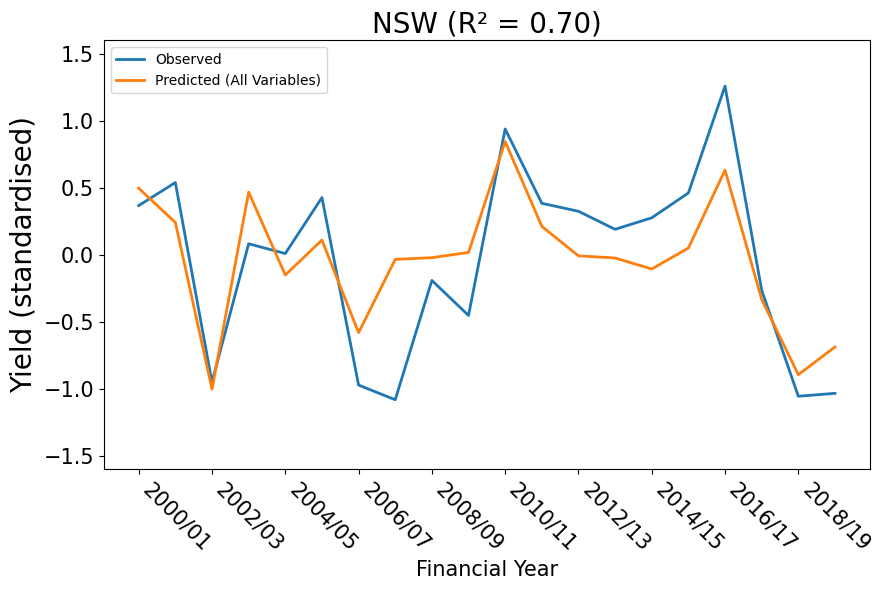

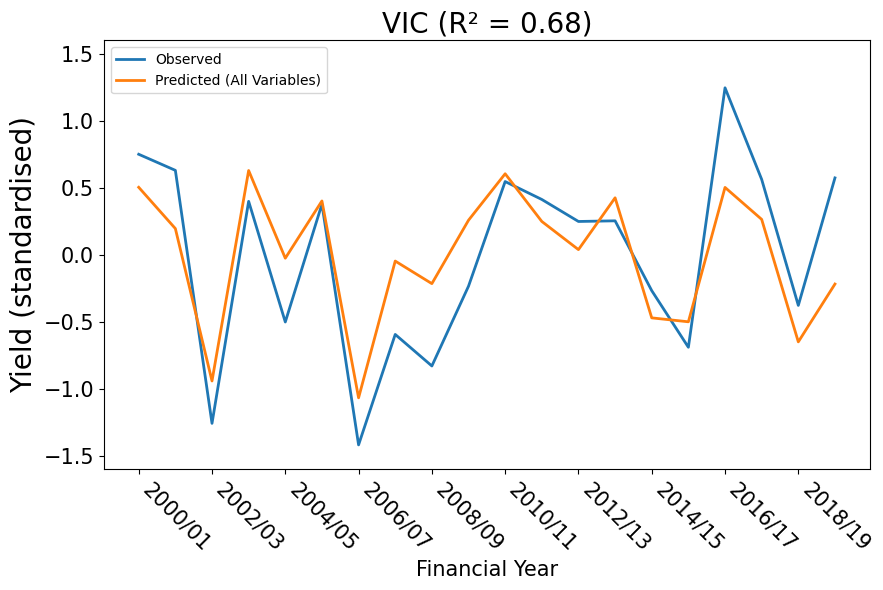

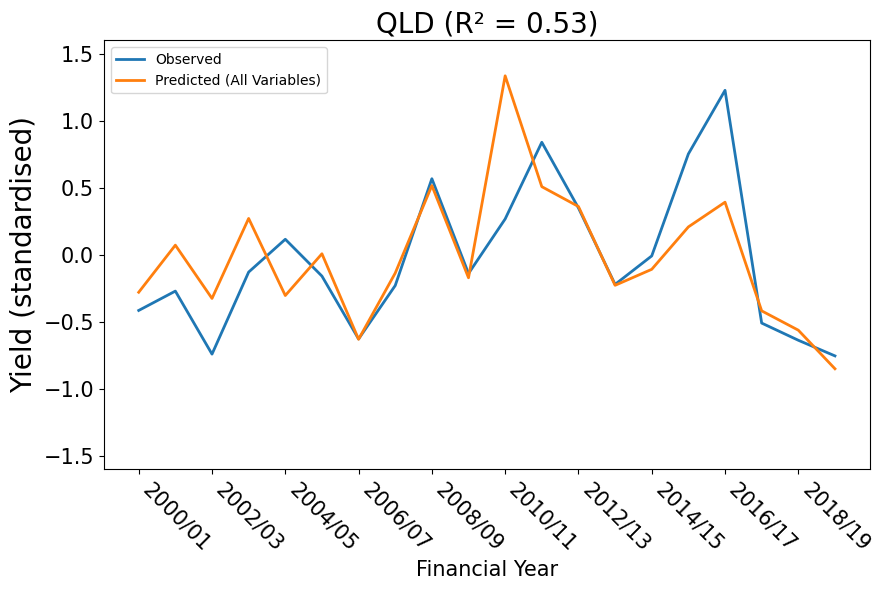

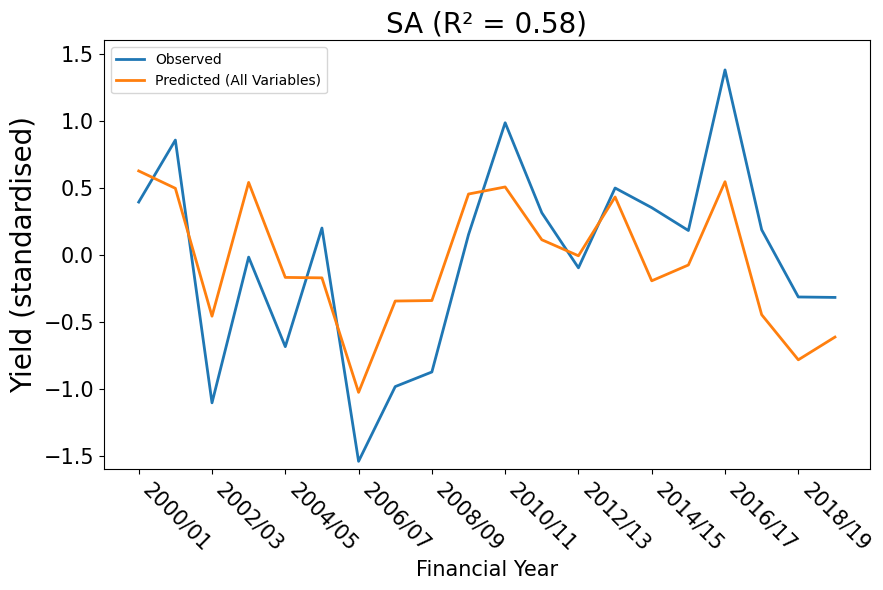

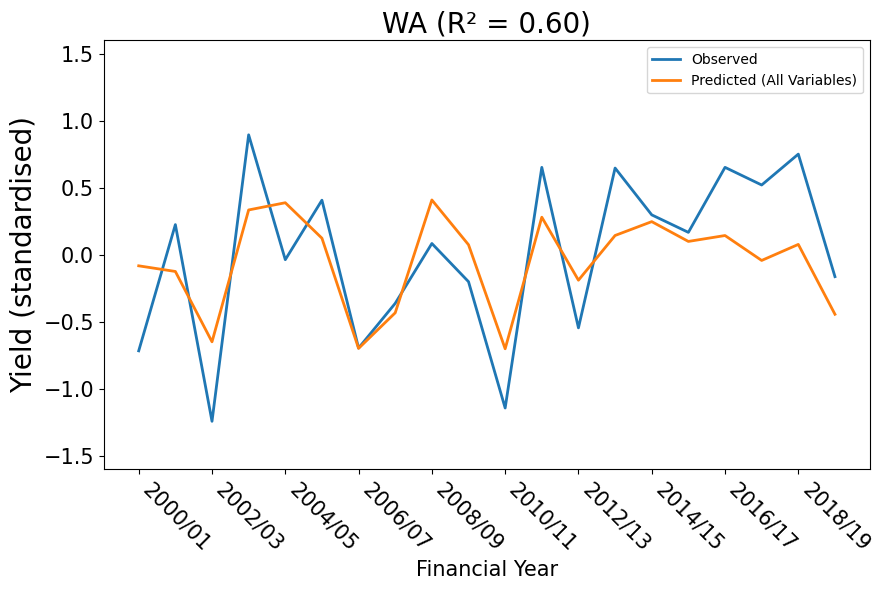

In [ ]:
states = ['NSW', 'VIC', 'QLD', 'SA', 'WA']

for state in states:
    state_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
#     ex_aus_yield = pd.read_csv(
#             f'{perf_datadir}/state_aggregated/extremes_only/full_season_only/single_drought_180/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
#     )
#     clim_aus_yield = pd.read_csv(
#             f'{perf_datadir}/state_aggregated/clim_only/full_season_only/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
#     )
    # Filter for seed 0
    df0 = state_yield[state_yield["seed"] == 0].sort_values("year")
#     df_ex = ex_aus_yield[ex_aus_yield["seed"] == 0].sort_values("year")
#     df_clim = clim_aus_yield[clim_aus_yield["seed"] == 0].sort_values("year")
    
    # Plot
    plt.figure(figsize=(9,6))
    
    plt.plot(df0["year"], df0["True"], label="Observed", linewidth=2)
    plt.plot(df0["year"], df0["Predicted"], label="Predicted (All Variables)", linewidth=2)
#     plt.plot(df_ex["year"], df_ex["Predicted"], label="Predicted (Extremes Only)", linewidth=2)
#     plt.plot(df_clim["year"], df_clim["Predicted"], label="Predicted (Non-extremes Only)", linewidth=2)

    years = df0["year"].unique()
    years_sorted = np.sort(years)
    tick_years = years_sorted[::2]   # every second year

    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    r2 = r2_value(df0["True"], df0["Predicted"])
    plt.xticks(tick_years, tick_labels, fontsize=15, rotation=-45, ha='left')
    plt.yticks(fontsize=15)
    plt.xlabel("Financial Year", fontsize=15)
    plt.ylabel("Yield (standardised)", fontsize=20)
    plt.ylim(-1.6, 1.6)
    plt.legend()
    plt.title(f'{state} (R² = {r2:.2f})', fontsize=20)
    plt.tight_layout()
    plt.show()


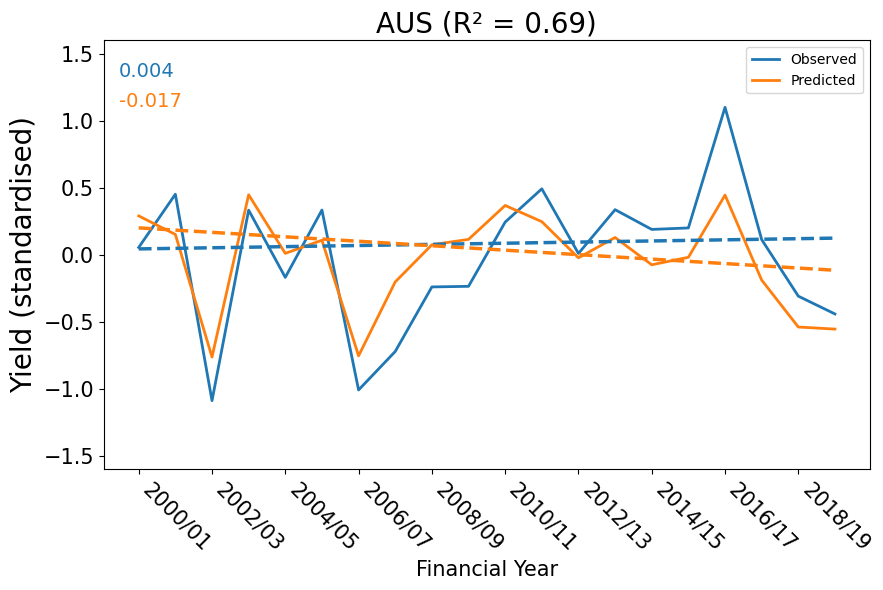

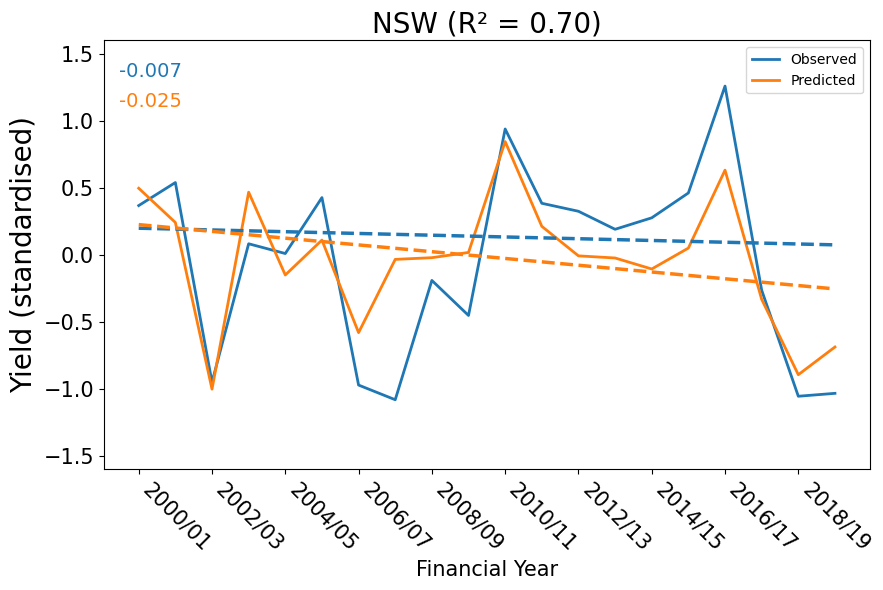

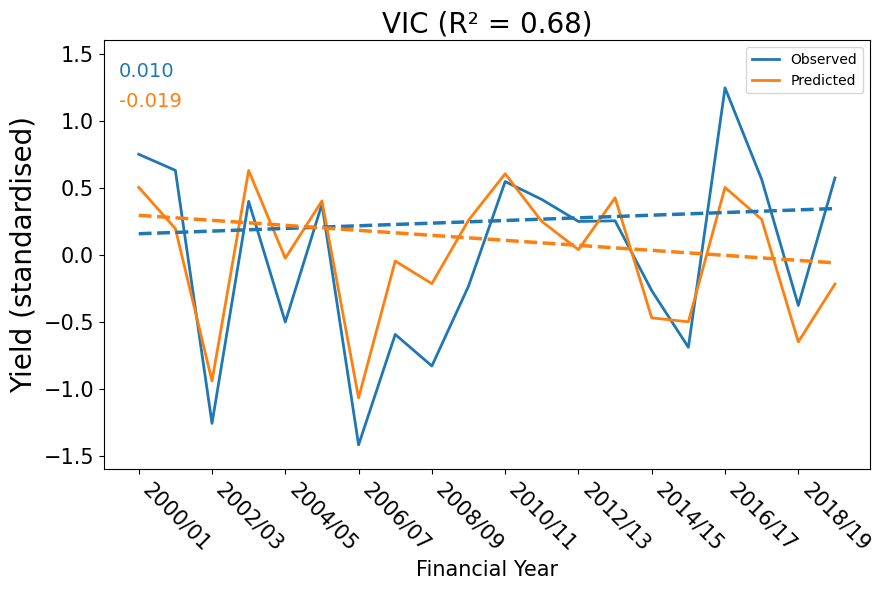

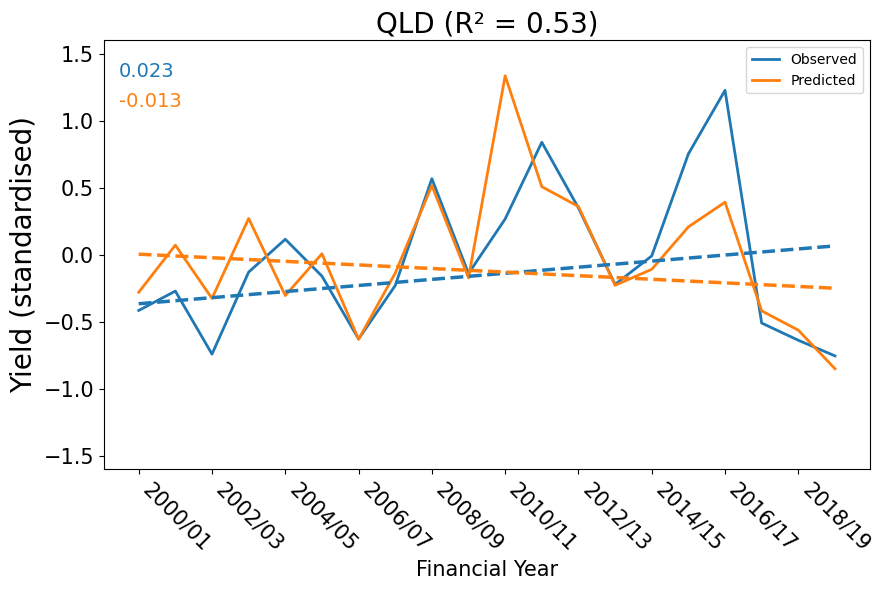

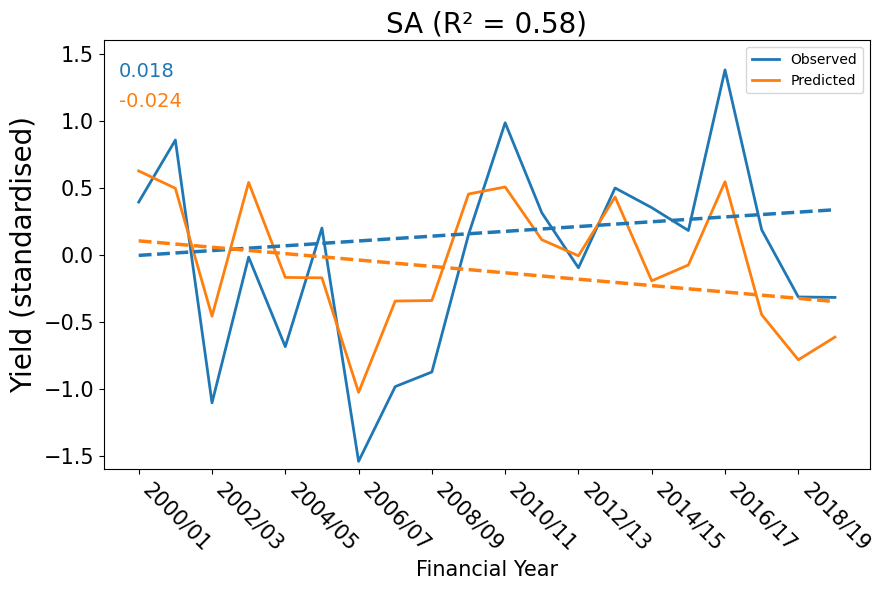

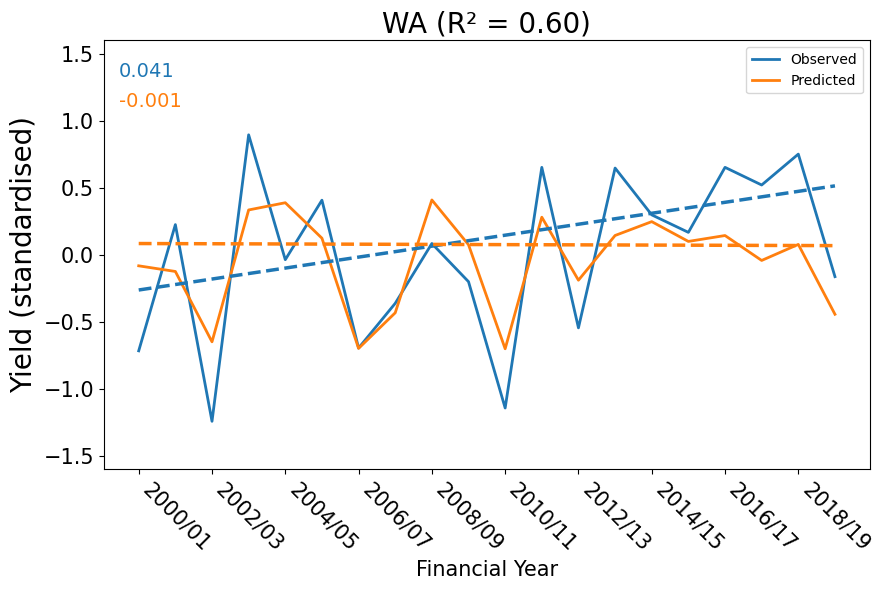

In [ ]:
import pymannkendall as mk
import matplotlib.colors as mcolors
import pandas as pd

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

for state in states:
    state_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/'
        f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )

    # Filter for seed 0
    df0 = state_yield[state_yield["seed"] == 0].sort_values("year")

    years = df0["year"].values
    true_vals = df0["True"].values
    pred_vals = df0["Predicted"].values

    # Financial year tick labels
    years_sorted = np.sort(np.unique(years))
    tick_years = years_sorted[::2]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    # --- Mann-Kendall tests ---
    mk_true = mk.original_test(true_vals)
    mk_pred = mk.original_test(pred_vals)

    slope_true = mk_true.slope
    slope_pred = mk_pred.slope
    intercept_true = mk_true.intercept
    intercept_pred = mk_pred.intercept

    sig_true = mk_true.p < 0.05
    sig_pred = mk_pred.p < 0.05

    # --- Colors ---
    col_true = "tab:blue"
    col_pred = "tab:orange"

    # Darkened versions for Sen slope lines
    dark_true = mcolors.to_hex(mcolors.to_rgba(col_true, alpha=1.0)[:3])
    dark_pred = mcolors.to_hex(mcolors.to_rgba(col_pred, alpha=1.0)[:3])

    # --- Plot ---
    plt.figure(figsize=(9,6))

    # Main time series
    plt.plot(years, true_vals, label="Observed", color=col_true, linewidth=2)
    plt.plot(years, pred_vals, label="Predicted", color=col_pred, linewidth=2)

    # --- Sen slope trend lines ---
    # y = slope * (x - x0) + y0
    true_trend = slope_true * np.arange(len(years)) + intercept_true
    pred_trend = slope_pred * np.arange(len(years)) + intercept_pred

    plt.plot(years, true_trend, color=dark_true, linewidth=2.5, linestyle="--")
    plt.plot(years, pred_trend, color=dark_pred, linewidth=2.5, linestyle="--")

    # --- Text annotations ---
    ax = plt.gca()

    text_true = f"{slope_true:.3f}{' ★' if sig_true else ''}"
    text_pred = f"{slope_pred:.3f}{' ★' if sig_pred else ''}"

    ax.text(
        0.02, 0.95, text_true,
        color=col_true, fontsize=14, va="top", ha="left",
        transform=ax.transAxes
    )

    ax.text(
        0.02, 0.88, text_pred,
        color=col_pred, fontsize=14, va="top", ha="left",
        transform=ax.transAxes
    )

    # --- Axes formatting ---
    r2 = r2_value(true_vals, pred_vals)

    plt.xticks(tick_years, tick_labels, fontsize=15, rotation=-45, ha='left')
    plt.yticks(fontsize=15)
    plt.xlabel("Financial Year", fontsize=15)
    plt.ylabel("Yield (standardised)", fontsize=20)
    plt.ylim(-1.6, 1.6)
    plt.title(f"{state} (R² = {r2:.2f})", fontsize=20)
    plt.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.stats import norm

def sen_slope_ci(x, var_s, alpha=0.05):
    """
    Compute confidence interval for Sen's slope estimator (Gilbert, 1987).
    x: 1D array of values (e.g. true_vals or pred_vals)
    var_s: variance of S statistic, from pymannkendall result (mk_result.var_s)
    alpha: significance level (default 0.05 -> 95% CI)
    """
    n = len(x)
    slopes = []
    for i in range(n - 1):
        for j in range(i + 1, n):
            slopes.append((x[j] - x[i]) / (j - i))
    slopes = np.sort(np.array(slopes))
    N = len(slopes)

    z = norm.ppf(1 - alpha / 2)
    C_alpha = z * np.sqrt(var_s)

    M1 = int(np.floor((N - C_alpha) / 2))
    M2 = int(np.ceil((N + C_alpha) / 2)) + 1

    M1 = max(M1, 0)
    M2 = min(M2, N - 1)

    lower_slope = slopes[M1]
    upper_slope = slopes[M2]

    return lower_slope, upper_slope

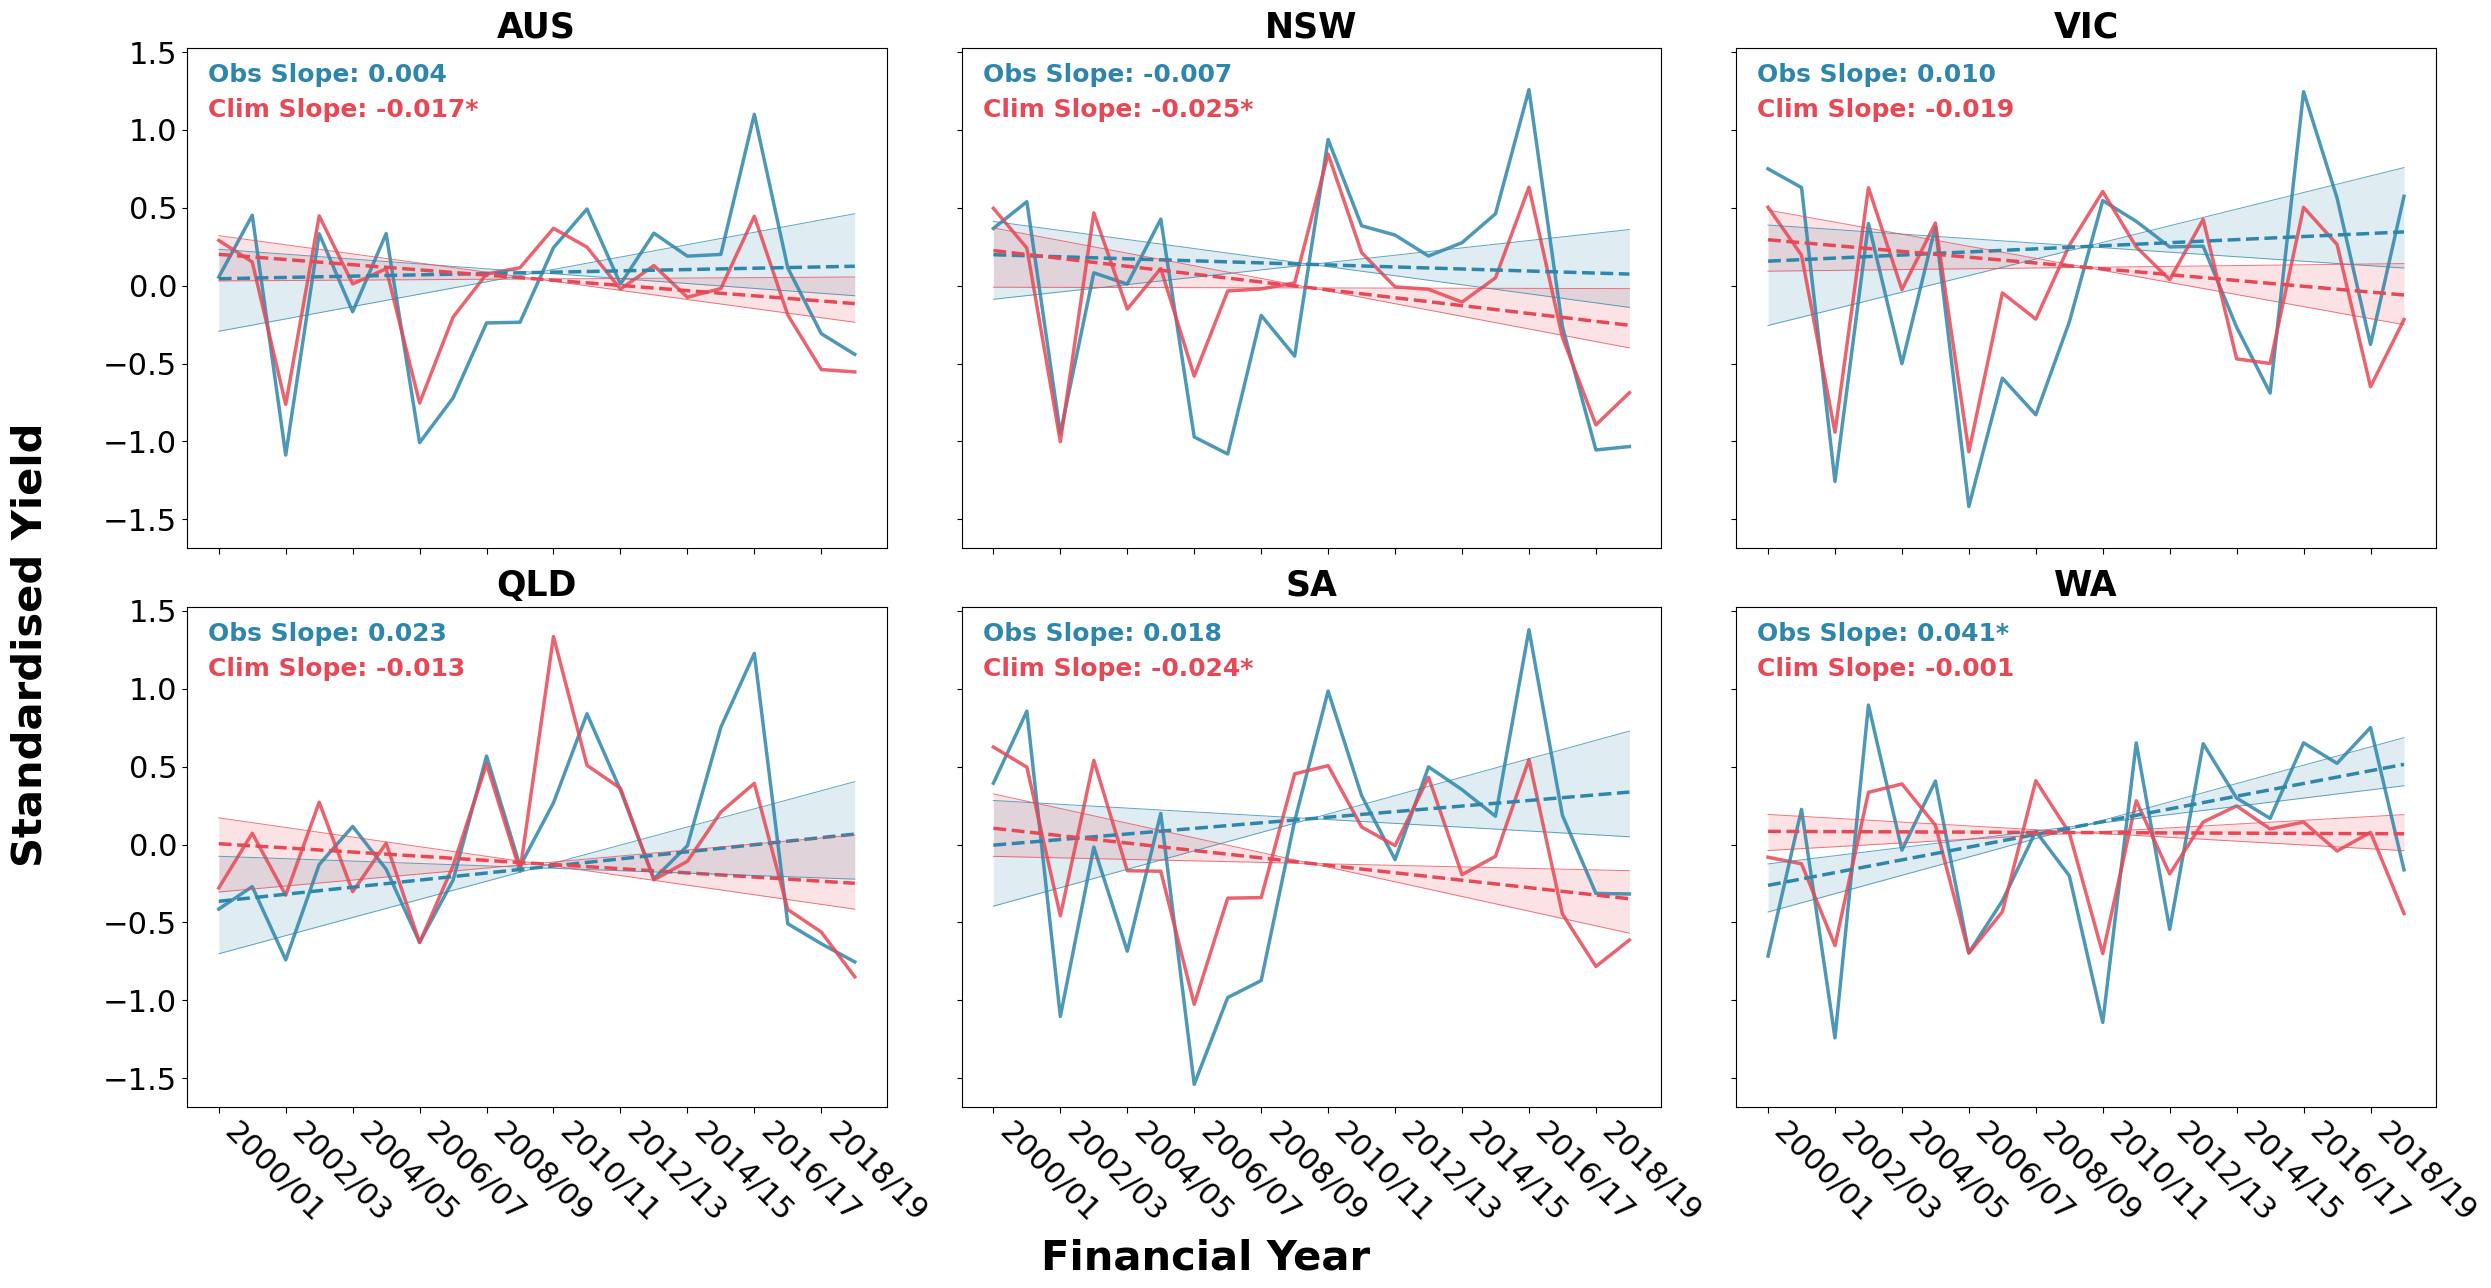

In [ ]:
import pymannkendall as mk
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

perf_datadir = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/performance_scores'
# Cool scientific palette
col_true = "#2E86AB"   # teal
col_pred = "#E84855"   # coral

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']
fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    state_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/'
        f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
    df0 = state_yield[state_yield["seed"] == 0].sort_values("year")
    years = df0["year"].values
    true_vals = df0["True"].values
    pred_vals = df0["Predicted"].values

    years_sorted = np.sort(np.unique(years))
    tick_years = years_sorted[::2]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]
    
    mk_true = mk.yue_wang_modification_test(true_vals)
    mk_pred = mk.yue_wang_modification_test(pred_vals)
    
    slope_true = mk_true.slope
    slope_pred = mk_pred.slope
    intercept_true = mk_true.intercept
    intercept_pred = mk_pred.intercept
    sig_true = mk_true.trend != "no trend"
    sig_pred = mk_pred.trend != "no trend"

    lower_slope_true, upper_slope_true = sen_slope_ci(true_vals, mk_true.var_s)
    lower_slope_pred, upper_slope_pred = sen_slope_ci(pred_vals, mk_pred.var_s)

    x_arange = np.arange(len(years))
    x_median = np.median(x_arange)

    median_true = np.median(true_vals)
    median_pred = np.median(pred_vals)

    # Median trend line, pivoted through (x_median, median value) -- equivalent to Sen's slope line
    true_trend = median_true + slope_true * (x_arange - x_median)
    pred_trend = median_pred + slope_pred * (x_arange - x_median)

    # Bounds pivot through the same point, fanning outwards in both directions
    lower_trend_true = median_true + lower_slope_true * (x_arange - x_median)
    upper_trend_true = median_true + upper_slope_true * (x_arange - x_median)
    lower_trend_pred = median_pred + lower_slope_pred * (x_arange - x_median)
    upper_trend_pred = median_pred + upper_slope_pred * (x_arange - x_median)

    # lower_trend_true = lower_slope_true * x_arange + intercept_true
    # upper_trend_true = upper_slope_true * x_arange + intercept_true
    # lower_trend_pred = lower_slope_pred * x_arange + intercept_pred
    # upper_trend_pred = upper_slope_pred * x_arange + intercept_pred   

    # true_trend = slope_true * np.arange(len(years)) + intercept_true
    # pred_trend = slope_pred * np.arange(len(years)) + intercept_pred

    ax.plot(years, true_vals, color=col_true, linewidth=2.5, alpha=0.85)
    ax.plot(years, pred_vals, color=col_pred, linewidth=2.5, alpha=0.85)

    ax.plot(years, true_trend, color=col_true, linewidth=2.5, linestyle="--")
    ax.plot(years, pred_trend, color=col_pred, linewidth=2.5, linestyle="--")


    ax.fill_between(years, lower_trend_true, upper_trend_true,
                     color=col_true, alpha=0.15, linewidth=0)
    ax.fill_between(years, lower_trend_pred, upper_trend_pred,
                     color=col_pred, alpha=0.15, linewidth=0)
    
    # Thin solid lines marking the CI bounds
    ax.plot(years, lower_trend_true, color=col_true, linewidth=0.7, alpha=0.75)
    ax.plot(years, upper_trend_true, color=col_true, linewidth=0.7, alpha=0.75)
    ax.plot(years, lower_trend_pred, color=col_pred, linewidth=0.7, alpha=0.75)
    ax.plot(years, upper_trend_pred, color=col_pred, linewidth=0.7, alpha=0.75)
    
    sig_marker_true = "*" if sig_true else ""
    sig_marker_pred = "*" if sig_pred else ""
    text_true = f"Obs Slope: {slope_true:.3f}{sig_marker_true}"
    text_pred = f"Clim Slope: {slope_pred:.3f}{sig_marker_pred}"
    # if state == 'QLD':
    #     text_y = [0.2, 0.13]
    # else:
    text_y = [0.97, 0.9]
    ax.text(0.03, text_y[0], text_true, color=col_true,
            fontsize=18, va="top", ha="left", transform=ax.transAxes,
            fontweight="bold")
    ax.text(0.03, text_y[1], text_pred, color=col_pred,
            fontsize=18, va="top", ha="left", transform=ax.transAxes,
            fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)

    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

# Shared axis labels
fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("yield_trends_publication.pdf", dpi=300, bbox_inches="tight")
plt.show()

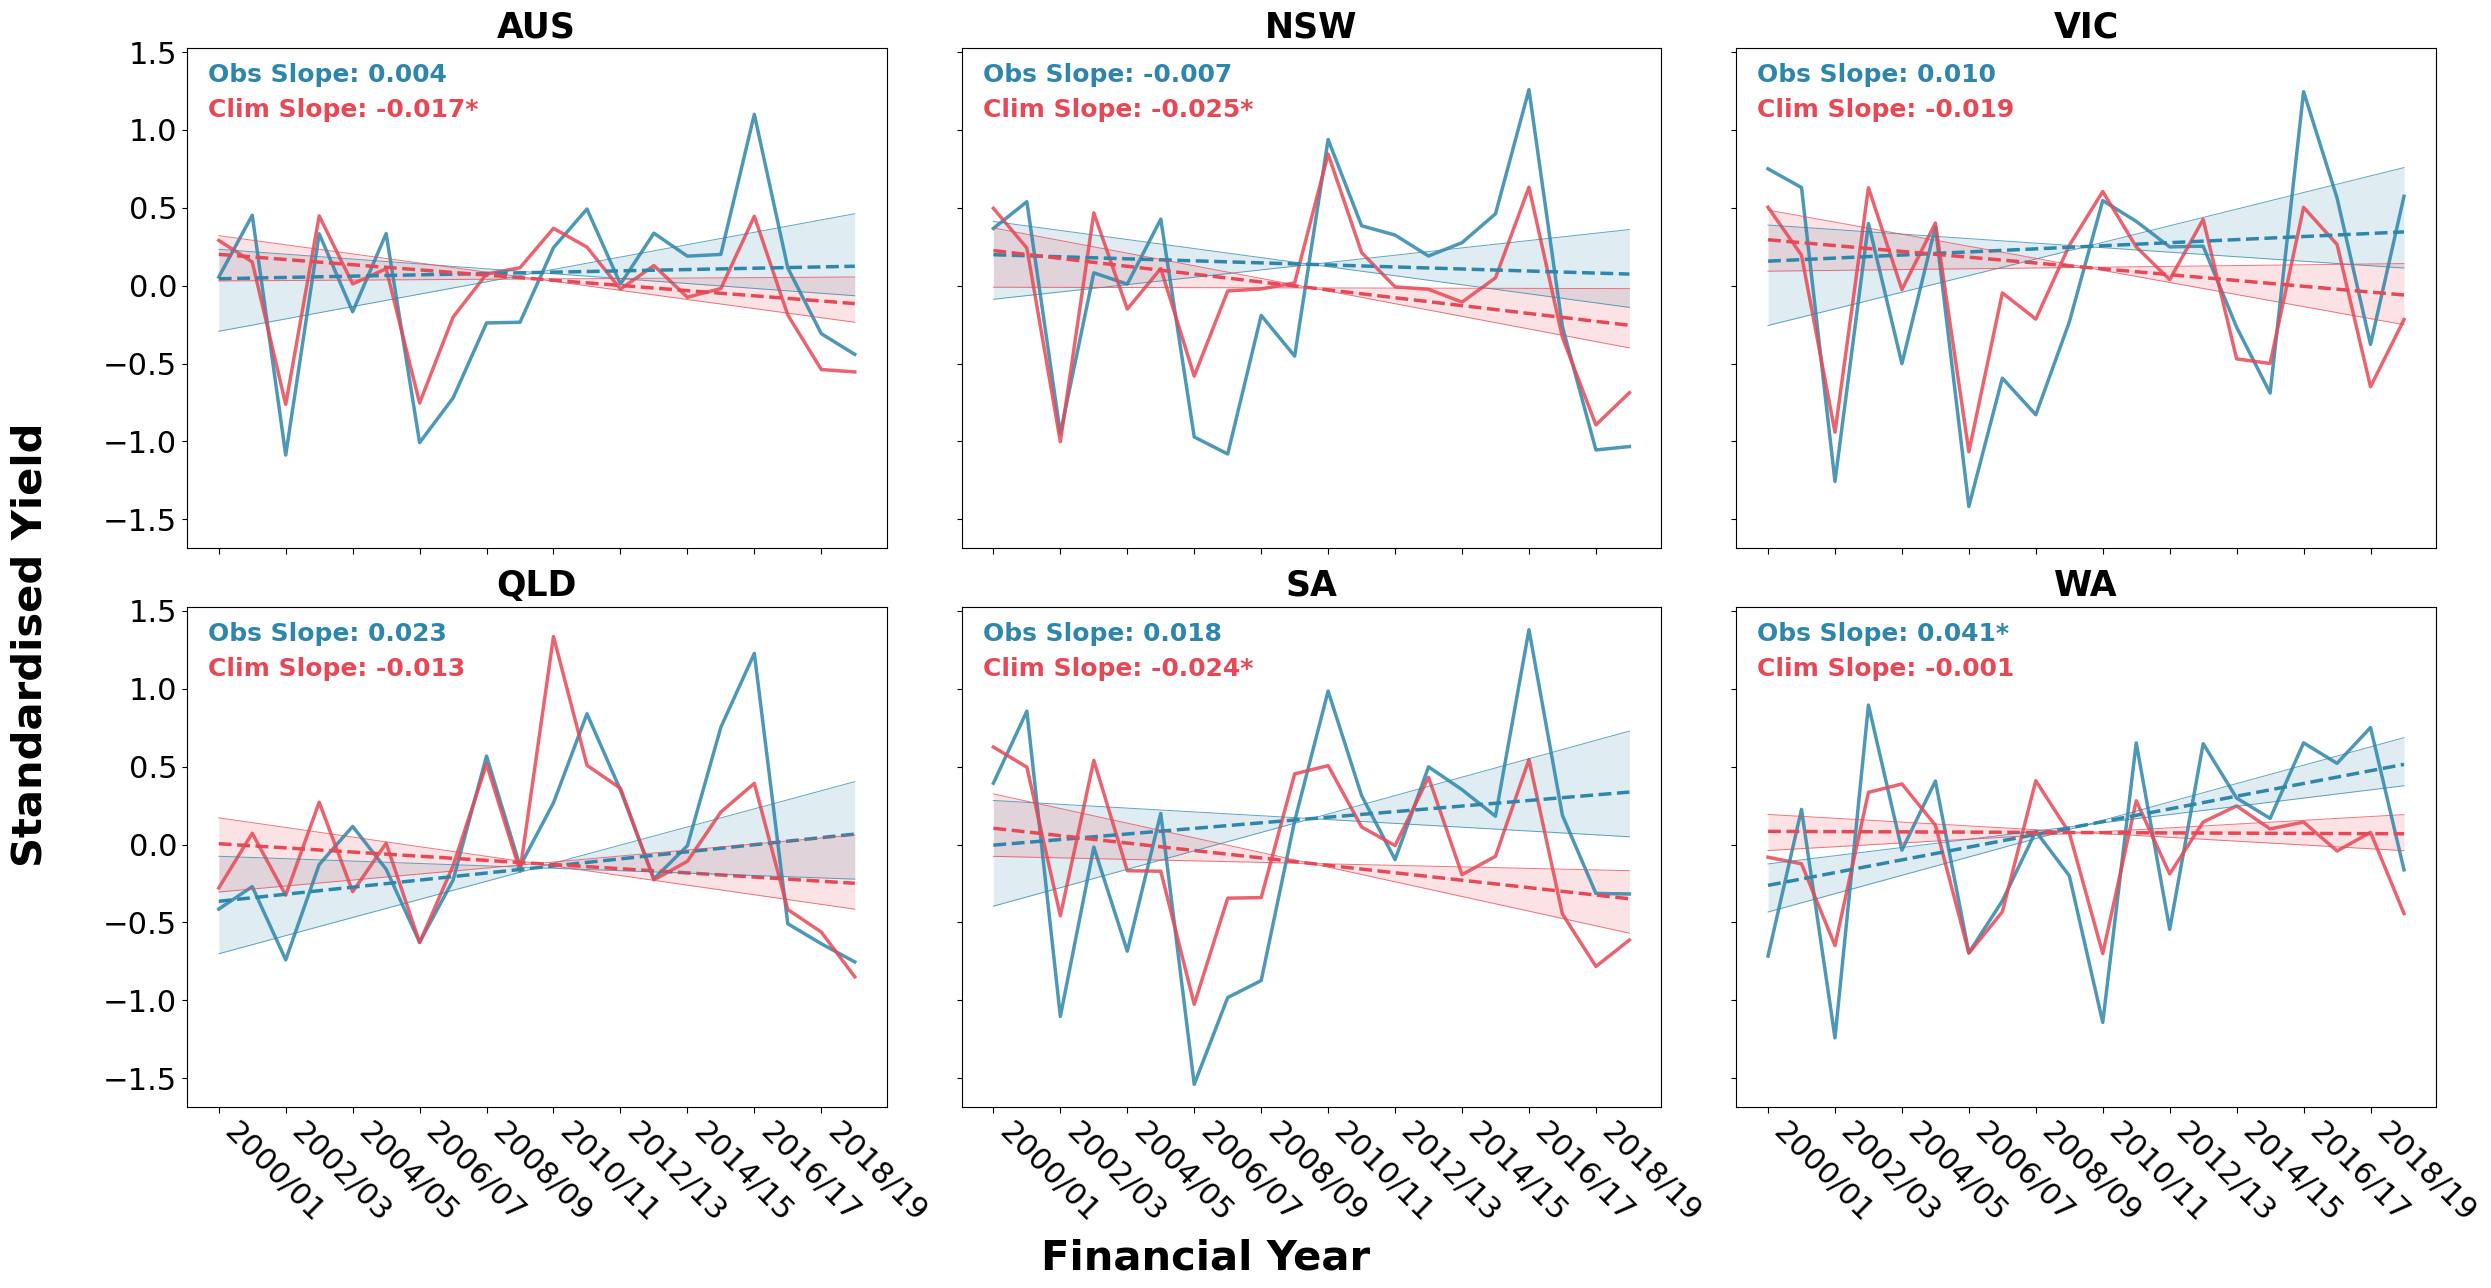

In [ ]:
import pymannkendall as mk
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model_datadir = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/modelled_yield/past_yield/'
# obs_datadir = 
# Cool scientific palette
col_true = "#2E86AB"   # teal
col_pred = "#E84855"   # coral

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']
fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    state_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/'
        f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
    df0 = state_yield[state_yield["seed"] == 0].sort_values("year")
    years = df0["year"].values
    true_vals = df0["True"].values
    pred_vals = df0["Predicted"].values

    years_sorted = np.sort(np.unique(years))
    tick_years = years_sorted[::2]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]
    
    mk_true = mk.yue_wang_modification_test(true_vals)
    mk_pred = mk.yue_wang_modification_test(pred_vals)
    
    slope_true = mk_true.slope
    slope_pred = mk_pred.slope
    intercept_true = mk_true.intercept
    intercept_pred = mk_pred.intercept
    sig_true = mk_true.trend != "no trend"
    sig_pred = mk_pred.trend != "no trend"

    lower_slope_true, upper_slope_true = sen_slope_ci(true_vals, mk_true.var_s)
    lower_slope_pred, upper_slope_pred = sen_slope_ci(pred_vals, mk_pred.var_s)

    x_arange = np.arange(len(years))
    x_median = np.median(x_arange)

    median_true = np.median(true_vals)
    median_pred = np.median(pred_vals)

    # Median trend line, pivoted through (x_median, median value) -- equivalent to Sen's slope line
    true_trend = median_true + slope_true * (x_arange - x_median)
    pred_trend = median_pred + slope_pred * (x_arange - x_median)

    # Bounds pivot through the same point, fanning outwards in both directions
    lower_trend_true = median_true + lower_slope_true * (x_arange - x_median)
    upper_trend_true = median_true + upper_slope_true * (x_arange - x_median)
    lower_trend_pred = median_pred + lower_slope_pred * (x_arange - x_median)
    upper_trend_pred = median_pred + upper_slope_pred * (x_arange - x_median)

    # lower_trend_true = lower_slope_true * x_arange + intercept_true
    # upper_trend_true = upper_slope_true * x_arange + intercept_true
    # lower_trend_pred = lower_slope_pred * x_arange + intercept_pred
    # upper_trend_pred = upper_slope_pred * x_arange + intercept_pred   

    # true_trend = slope_true * np.arange(len(years)) + intercept_true
    # pred_trend = slope_pred * np.arange(len(years)) + intercept_pred

    ax.plot(years, true_vals, color=col_true, linewidth=2.5, alpha=0.85)
    ax.plot(years, pred_vals, color=col_pred, linewidth=2.5, alpha=0.85)

    ax.plot(years, true_trend, color=col_true, linewidth=2.5, linestyle="--")
    ax.plot(years, pred_trend, color=col_pred, linewidth=2.5, linestyle="--")


    ax.fill_between(years, lower_trend_true, upper_trend_true,
                     color=col_true, alpha=0.15, linewidth=0)
    ax.fill_between(years, lower_trend_pred, upper_trend_pred,
                     color=col_pred, alpha=0.15, linewidth=0)
    
    # Thin solid lines marking the CI bounds
    ax.plot(years, lower_trend_true, color=col_true, linewidth=0.7, alpha=0.75)
    ax.plot(years, upper_trend_true, color=col_true, linewidth=0.7, alpha=0.75)
    ax.plot(years, lower_trend_pred, color=col_pred, linewidth=0.7, alpha=0.75)
    ax.plot(years, upper_trend_pred, color=col_pred, linewidth=0.7, alpha=0.75)
    
    sig_marker_true = "*" if sig_true else ""
    sig_marker_pred = "*" if sig_pred else ""
    text_true = f"Obs Slope: {slope_true:.3f}{sig_marker_true}"
    text_pred = f"Clim Slope: {slope_pred:.3f}{sig_marker_pred}"
    # if state == 'QLD':
    #     text_y = [0.2, 0.13]
    # else:
    text_y = [0.97, 0.9]
    ax.text(0.03, text_y[0], text_true, color=col_true,
            fontsize=18, va="top", ha="left", transform=ax.transAxes,
            fontweight="bold")
    ax.text(0.03, text_y[1], text_pred, color=col_pred,
            fontsize=18, va="top", ha="left", transform=ax.transAxes,
            fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)

    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

# Shared axis labels
fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("yield_trends_publication.pdf", dpi=300, bbox_inches="tight")
plt.show()

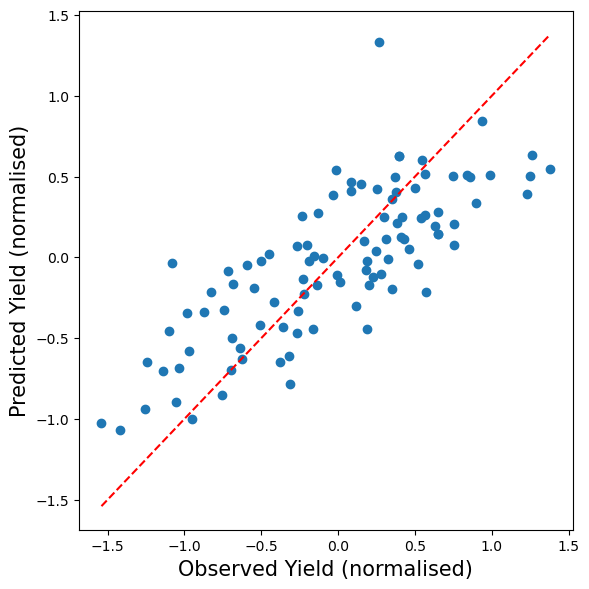

In [ ]:
states = ["NSW", "VIC", "QLD", "SA", "WA"]

dfs = []

for state in states:
    df = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
    
    df["state"] = state   # add state identifier
    dfs.append(df)

# Combine all states
all_states_df = pd.concat(dfs, ignore_index=True)

df0 = all_states_df[all_states_df["seed"] == 0].sort_values("year")
r2 = df0["True"].corr(df0["Predicted"]) ** 2

plt.figure(figsize=(6,6))

plt.scatter(df0["True"], df0["Predicted"])

# 1:1 reference line
min_val = min(df0["True"].min(), df0["Predicted"].min())
max_val = max(df0["True"].max(), df0["Predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Observed Yield (normalised)", fontsize=15)
plt.ylabel("Predicted Yield (normalised)", fontsize=15)
# plt.text(0.05, 0.95, f"R² = {r2:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
# plt.title("Observed vs Predicted Yield (Seed 0)")

plt.tight_layout()
plt.show()

In [ ]:
aus_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/RandomForestRegressor_AUS_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
)

# Filter for seed 0
df0 = df[df["seed"] == 0].sort_values("year")



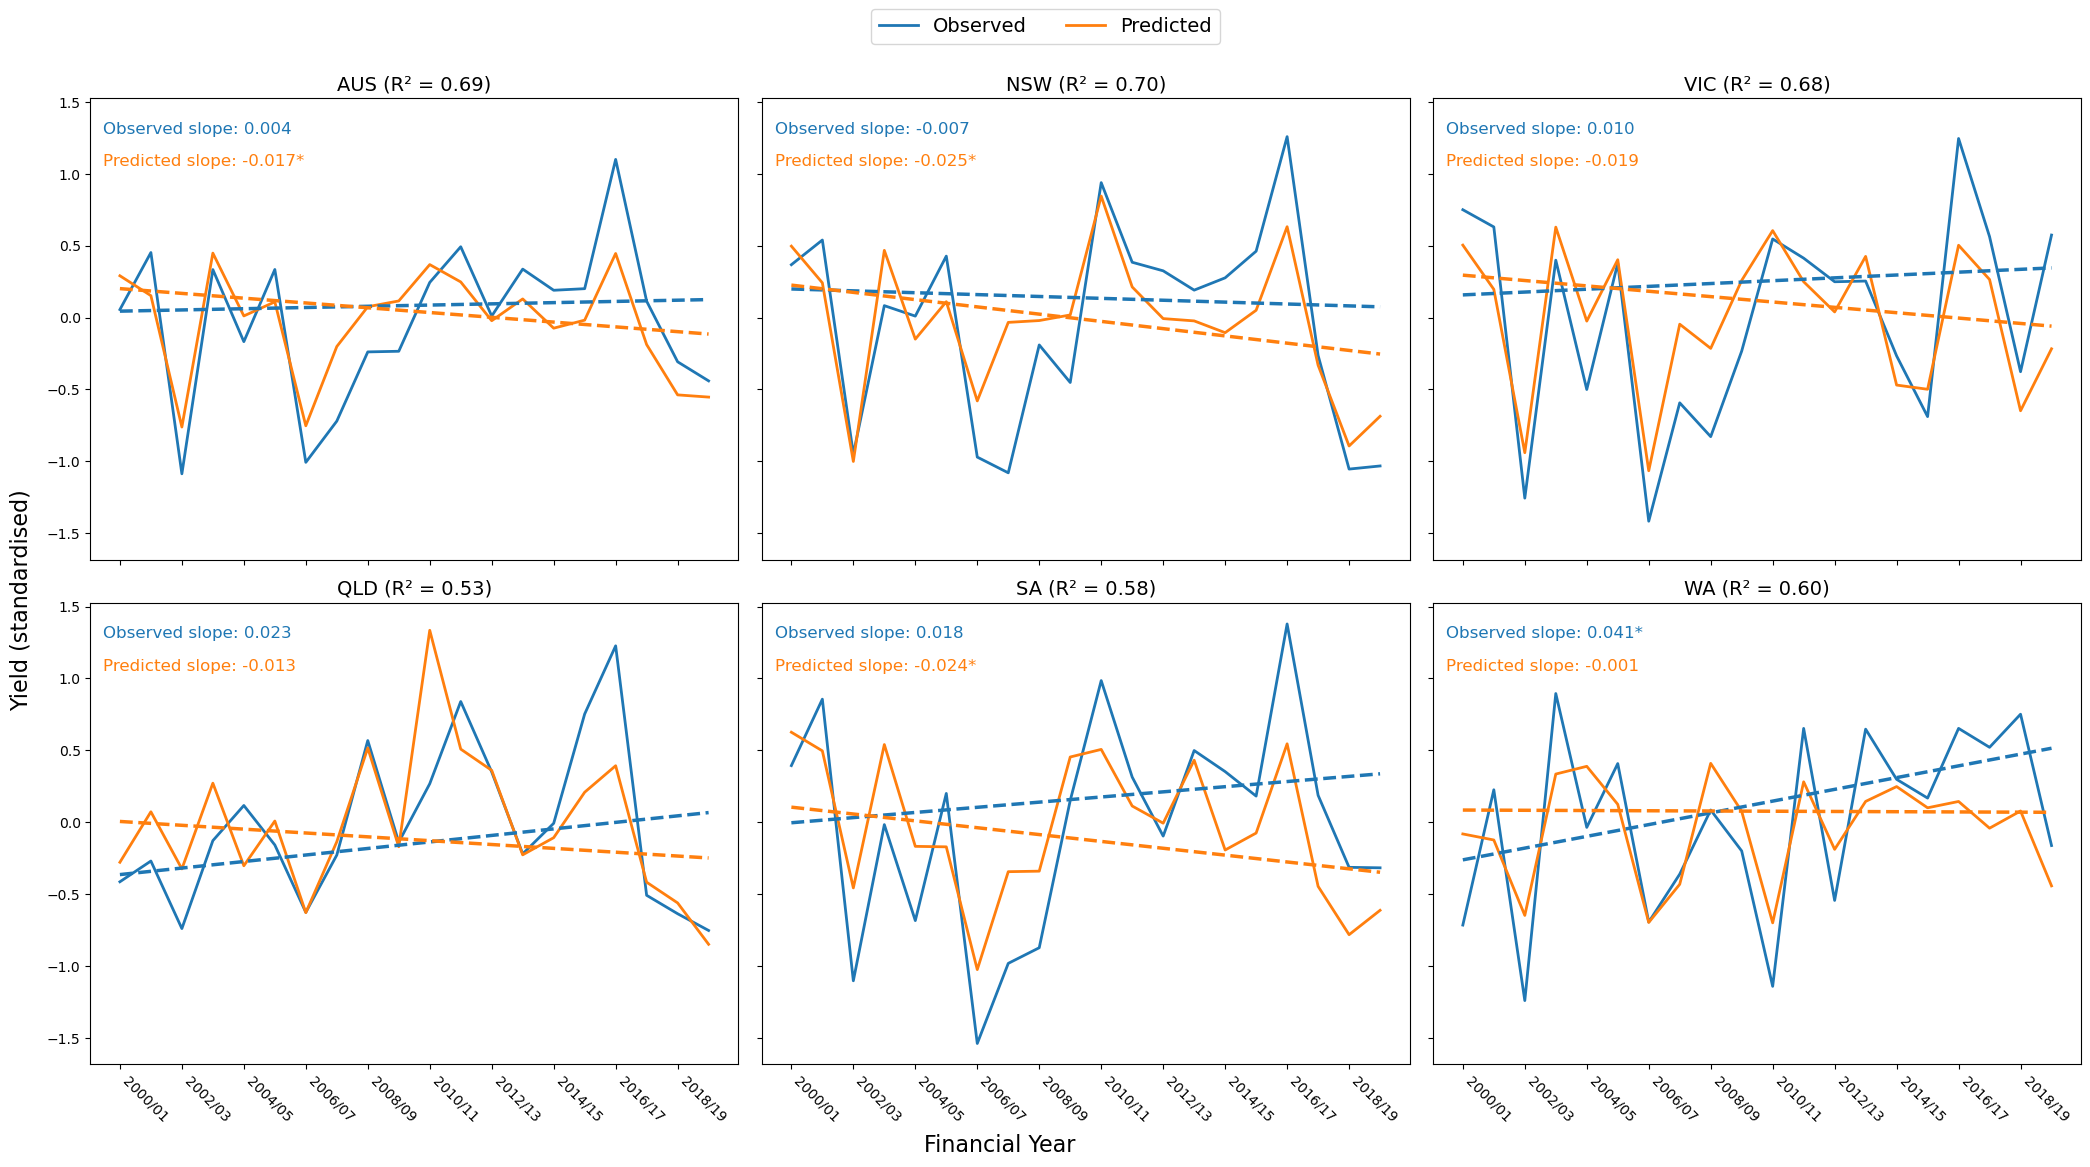

In [ ]:
import pymannkendall as mk
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):

    state_yield = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/'
        f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )

    df0 = state_yield[state_yield["seed"] == 0].sort_values("year")

    years = df0["year"].values
    true_vals = df0["True"].values
    pred_vals = df0["Predicted"].values

    years_sorted = np.sort(np.unique(years))
    tick_years = years_sorted[::2]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    # mk_true = mk.original_test(true_vals)
    # mk_pred = mk.original_test(pred_vals)
    mk_true = mk.yue_wang_modification_test(true_vals)
    mk_pred = mk.yue_wang_modification_test(pred_vals)

    slope_true = mk_true.slope
    slope_pred = mk_pred.slope

    intercept_true = mk_true.intercept
    intercept_pred = mk_pred.intercept

    sig_true = mk_true.trend != "no trend"
    sig_pred = mk_pred.trend != "no trend"

    col_true = "tab:blue"
    col_pred = "tab:orange"

    dark_true = mcolors.to_hex(mcolors.to_rgba(col_true, alpha=1.0)[:3])
    dark_pred = mcolors.to_hex(mcolors.to_rgba(col_pred, alpha=1.0)[:3])

    ax.plot(years, true_vals, label="Observed", color=col_true, linewidth=2)
    ax.plot(years, pred_vals, label="Predicted", color=col_pred, linewidth=2)

    true_trend = slope_true * np.arange(len(years)) + intercept_true
    pred_trend = slope_pred * np.arange(len(years)) + intercept_pred

    ax.plot(years, true_trend, color=dark_true, linewidth=2.5, linestyle="--")
    ax.plot(years, pred_trend, color=dark_pred, linewidth=2.5, linestyle="--")

    text_true = f"Observed slope: {slope_true:.3f}{'*' if sig_true else ''}"
    text_pred = f"Predicted slope: {slope_pred:.3f}{'*' if sig_pred else ''}"

    ax.text(0.02, 0.95, text_true, color=col_true,
            fontsize=12, va="top", ha="left", transform=ax.transAxes)
    ax.text(0.02, 0.88, text_pred, color=col_pred,
            fontsize=12, va="top", ha="left", transform=ax.transAxes)

    r2 = r2_value(true_vals, pred_vals)
    ax.set_title(f"{state} (R² = {r2:.2f})", fontsize=14)

    # Set ticks only once (shared)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=10)

    ax.tick_params(axis='y', labelsize=10)

# Shared axis labels
fig.text(0.5, 0.04, "Financial Year", ha='center', fontsize=16)
fig.text(0.05, 0.5, "Yield (standardised)", 
         va='center', rotation='vertical', fontsize=16)

# One legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=14)

plt.tight_layout(rect=[0.06, 0.05, 1, 0.95])
plt.show()


## Single season feature importance

In [ ]:
def plot_top3_predictors(top3):
    # Sort within each state so bars go top → bottom
    top3 = top3.sort_values(["state", "mean"], ascending=[True, False])

    # Build y positions
    y_positions = []
    labels = []
    state_positions = {}

    y = 3*len(states) + 3
    for state in states:
        subset = top3[top3["state"] == state].sort_values("mean", ascending=False)
        n = len(subset)

        state_positions[state] = y + (n-1)/2 - 0.4

        for _, row in subset.iterrows():
            y_positions.append(y)
            labels.append(row["predictor"])
            y -= 1

        y -= 1.5

    top3["y"] = y_positions

    # --- Assign colors based on predictor name ---
    def pick_color(name):
        name_lower = name.lower()
        if "drought" in name_lower:
            return "#8c510a"   # warm earthy brown
        if "frost" in name_lower:
            return "#74a9cf"   # icy blue
        if "heatwave" in name_lower:
            return "#d73027"   # hot red
        return "steelblue"     # default

    top3["color"] = top3["predictor"].apply(pick_color)

    # --- Plot ---
    plt.figure(figsize=(10, 8))

    plt.barh(
        top3["y"],
        top3["mean"],
        xerr=[top3["lower"], top3["upper"]],
        capsize=5,
        color=top3["color"],
        edgecolor="black"
    )

    plt.xlabel("Feature importance", fontsize=15)

    # Predictor labels
    plt.yticks(top3["y"], labels)

    # State labels on the left
    for state in states:
        plt.text(
            -0.02,
            state_positions[state],
            state,
            va="center",
            ha="right",
            fontsize=15,
            fontweight="bold",
            transform=plt.gca().transData
        )

    plt.tight_layout()
    plt.show()


In [ ]:
def find_top3_predictors_per_state(variables, stages):
    states = ["NSW", "VIC", "QLD", "SA", "WA"]

    top3_list = []

    for state in states:
        df = pd.read_csv(f"{import_datadir}{variables}/{stages}/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
        
        # Compute stats across seeds
        mean_imp = df.mean(axis=0)
        min_imp  = df.min(axis=0)
        max_imp  = df.max(axis=0)
        
        summary = pd.DataFrame({
            "predictor": mean_imp.index,
            "mean": mean_imp.values,
            "min": min_imp.values,
            "max": max_imp.values
        })
        
        summary["lower"] = summary["mean"] - summary["min"]
        summary["upper"] = summary["max"] - summary["mean"]
        summary["state"] = state
        
        # Select top 3 predictors
        summary = summary.sort_values("mean", ascending=False).head(3)
        summary['predictor'] = summary['predictor'].apply(transform_name)

        top3_list.append(summary)

    # Combine all states
    top3 = pd.concat(top3_list, ignore_index=True)
    return top3

In [ ]:
top3_planting = find_top3_predictors_per_state('extremes_only', 'planting_season')
plot_top3_predictors(top3_planting)

In [ ]:
top3_mid = find_top3_predictors_per_state('extremes_only', 'mid_season')
plot_top3_predictors(top3_mid)

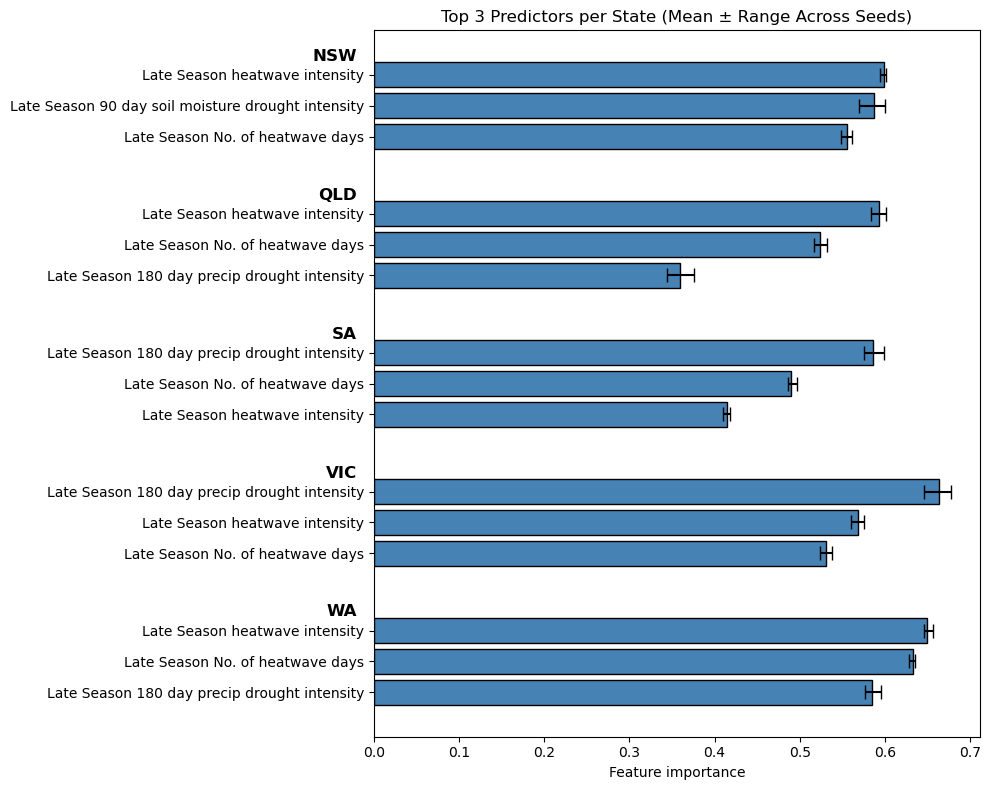

In [ ]:
top3_harvest = find_top3_predictors_per_state('extremes_only', 'harvest_season')
plot_top3_predictors(top3_harvest)